**🌐 Language:** [English →](/fuzzy-rdd-en) | **한국어**

# Fuzzy RDD

<small><em>작성자 손지우 · <a href="https://github.com/bungaedm">GitHub</a> · <a href="https://www.linkedin.com/in/jiwoo-son-3207021a7/">LinkedIn</a></em></small>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import warnings

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(2026)
warnings.filterwarnings('ignore')

## Recap. Sharp vs Fuzzy RDD

앞 챕터에서 Sharp RDD를 배웠습니다. Sharp RDD에서 임계점 $c$는 처치를 **완전히** 결정합니다.

$$D_i^{\text{Sharp}} = \mathbf{1}[X_i \geq c]$$

수능 70점 기준으로 70점 이상이면 반드시 장학금을 받고, 미만이면 절대 못 받는 구조입니다.

하지만 현실에서는 이런 "완벽한 규칙"이 드뭅니다. 70점을 넘어도 신청을 하지 않거나, 서류 미비로 탈락하거나, 반대로 69점이어도 재심사를 통해 받는 경우가 생깁니다. 이처럼 임계점이 처치 확률에 **불연속적인 영향**을 주지만 완전히 결정하지는 않는 경우를 **Fuzzy RDD**라고 합니다.

$$\lim_{x \rightarrow c+} \Pr(D_i = 1 \mid X_i = x) \;\neq\; \lim_{x \rightarrow c-} \Pr(D_i = 1 \mid X_i = x)$$

| 구분 | 처치 결정 방식 | 임계점에서 변화 | 추정 방법 |
|------|-------------|--------------|---------|
| **Sharp RDD** | $D_i = \mathbf{1}[X_i \geq c]$ | 처치 확률 0 → 1 | OLS (불연속 회귀) |
| **Fuzzy RDD** | $\Pr(D_i=1)$이 $c$에서 불연속 | 처치 확률 일부 점프 (예: 15% → 65%) | 2SLS (IV) |

![rdd types](images/rdd_types.png)

## 1. Fuzzy RDD란?

한 줄로 요약하자면, Fuzzy RDD는 컷오프가 treatment를 "강제"하지 않을 때의 RDD입니다.

예를 들자면, 수능 70점을 기준으로 장학금 **신청 자격**이 생긴다고 합시다. Sharp RDD라면 자격이 생기는 순간 모두가 장학금을 받을 것입니다. 하지만 현실은 이렇습니다.

- 71점을 받아 자격은 생겼지만 신청 기간을 놓친 학생
- 72점이어도 제출 서류가 미비해서 탈락한 학생
- 75점이어도 부유한 가정이라 신청하지 않은 학생

반대로 68점이어도 재심사나 특별 전형으로 받게 되는 경우도 있습니다.

임계점은 **자격(eligibility)**을 결정하지만, 실제 처치는 그 자격에 반드시 따르지 않습니다. 이것이 Fuzzy RDD의 세계입니다.

이 상황에서 핵심 변수를 구분해야 합니다.

- $X_i$: 수능 점수 (Running variable)
- $Z_i = \mathbf{1}[X_i \geq 70]$: 장학금 **자격 여부** (도구변수)
- $D_i$: 실제 장학금 **수혜 여부** (처치변수)
- $Y_i$: GPA (결과변수)

Sharp RDD에서는 $Z_i = D_i$였습니다. Fuzzy RDD에서는 $Z_i \neq D_i$입니다. $Z_i$가 $D_i$에 영향을 주지만, 완전히 결정하지는 않습니다.

## 2. 추정 대상

Fuzzy RDD가 추정하는 대상은 **순응자(Compliers)**에 한정된 LATE입니다.

도구변수 $Z_i$의 값(자격 여부)에 따라 개체를 네 유형으로 분류할 수 있습니다.

In [10]:
pd.DataFrame({
    '유형': ['순응자 (Complier)', '항상 수혜자 (Always-taker)', '절대 비수혜자 (Never-taker)', '위반자 (Defier)'],
    'Z=0일 때 D': [0, 1, 0, 1],
    'Z=1일 때 D': [1, 1, 0, 0],
    '설명': [
        '자격이 생겼을 때만 처치를 받는다 ← 추정 대상',
        '자격과 무관하게 항상 처치를 받는다',
        '자격이 생겨도 처치를 받지 않는다',
        '자격이 생기면 오히려 처치를 거부한다 (단조성 가정으로 배제)',
    ]
})

,유형,Z=0일 때 D,Z=1일 때 D,설명
0,순응자 (Complier),0,1,자격이 생겼을 때만 처치를 받는다 ← 추정 대상
1,항상 수혜자 (Always-taker),1,1,자격과 무관하게 항상 처치를 받는다
2,절대 비수혜자 (Never-taker),0,0,자격이 생겨도 처치를 받지 않는다
3,위반자 (Defier),1,0,자격이 생기면 오히려 처치를 거부한다 (단조성 가정으로 배제)


단조성(Monotonicity) 가정 하에서 위반자(Defier)는 없다고 가정합니다. 그러면 임계점 근방에서 추정되는 효과는:

$$\tau_{Fuzzy} = \mathbb{E}[Y_i(1) - Y_i(0) \mid \text{Complier},\; X_i = c]$$

즉, 자격이 생겼기 때문에 처치를 받게 된 사람들(순응자)의, 임계점 근방에서의, 처치 효과입니다.

**ATE(전체 평균 처치 효과)와의 차이**: Always-taker나 Never-taker는 포함되지 않습니다. 자격과 무관하게 항상 받거나 항상 안 받는 사람들의 효과는 추정하지 못합니다. 이것이 Fuzzy RDD의 근본적인 한계이자, 동시에 정직한 추정입니다.

## 3. 핵심가정 (도구변수)

Fuzzy RDD는 본질적으로 **도구변수(Instrumental Variable)** 추정 문제입니다.

$Z_i = \mathbf{1}[X_i \geq c]$를 도구변수로 씁니다. 이 도구변수가 유효하려면 세 가지 조건을 만족해야 합니다.

### 관련성 (Relevance)

$Z_i$는 $D_i$에 실질적으로 영향을 주어야 합니다. 자격이 생기면 처치 확률이 올라가야 합니다.

$$\text{Cov}(Z_i,\, D_i) \neq 0$$

1단계 회귀의 F-통계량으로 확인합니다. 통상 $F > 10$이면 강한 도구변수로 판단합니다.

### 배제 제약 (Exclusion Restriction)

$Z_i$는 $D_i$를 통해서만 $Y_i$에 영향을 주어야 합니다. 즉, 70점 기준을 넘는다는 사실 자체가 GPA를 직접 바꾸지는 않아야 합니다. 장학금을 받았기 때문에 GPA가 오르는 것이지, 자격이 생겼다는 것만으로 오르면 안 됩니다.

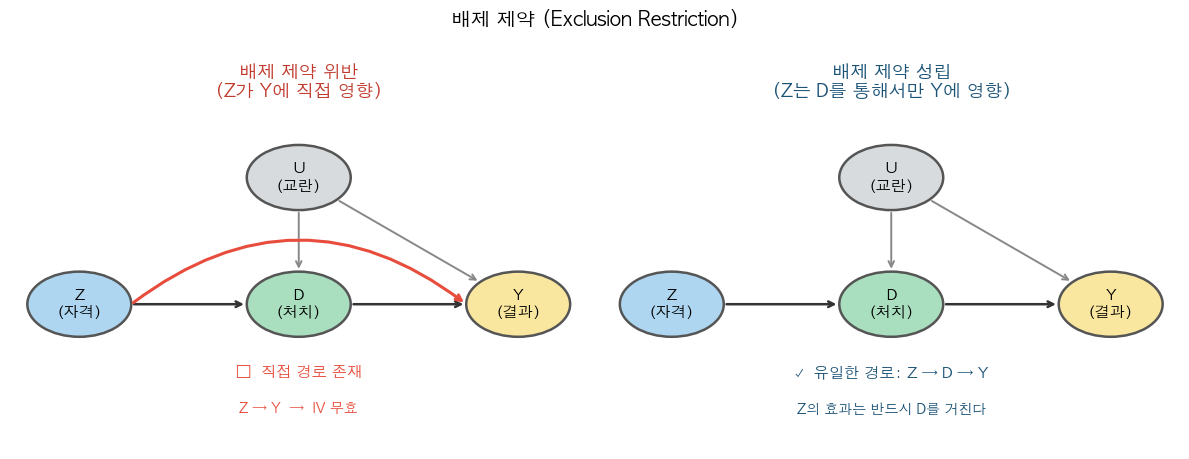

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

pos = {'Z': (0.12, 0.50), 'D': (0.50, 0.50), 'Y': (0.88, 0.50), 'U': (0.50, 0.85)}
node_colors = {'Z': '#AED6F1', 'D': '#A9DFBF', 'Y': '#F9E79F', 'U': '#D7DBDD'}
node_labels = {'Z': 'Z\n(자격)', 'D': 'D\n(처치)', 'Y': 'Y\n(결과)', 'U': 'U\n(교란)'}
R = 0.09

def draw_nodes(ax):
    for name, (x, y) in pos.items():
        circle = plt.Circle((x, y), R, color=node_colors[name], ec='#555', lw=1.8, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, node_labels[name], ha='center', va='center', fontsize=11,
                fontweight='bold', zorder=4, linespacing=1.3)

def arrow(ax, a, b, color='#333', lw=1.8, rad=0.0, ls='-'):
    x1, y1 = pos[a]; x2, y2 = pos[b]
    dx, dy = x2 - x1, y2 - y1
    dist = (dx**2 + dy**2) ** 0.5
    sx = x1 + R * dx / dist;  sy = y1 + R * dy / dist
    ex = x2 - R * dx / dist;  ey = y2 - R * dy / dist
    style = f'arc3,rad={rad}' if rad != 0 else 'arc3,rad=0'
    ax.annotate('', xy=(ex, ey), xytext=(sx, sy),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw,
                                connectionstyle=style,
                                linestyle=ls))

# ── 왼쪽: 배제 제약 위반 ──
ax = axes[0]
ax.set_xlim(0, 1); ax.set_ylim(0.1, 1.05); ax.axis('off')
ax.set_title('배제 제약 위반\n(Z가 Y에 직접 영향)', fontsize=13, fontweight='bold', color='#C0392B')
draw_nodes(ax)
arrow(ax, 'Z', 'D')
arrow(ax, 'D', 'Y')
arrow(ax, 'U', 'D', color='#888', lw=1.4)
arrow(ax, 'U', 'Y', color='#888', lw=1.4)
arrow(ax, 'Z', 'Y', color='#E74C3C', lw=2.2, rad=-0.38)   # 직접 경로 (위반)
# ✗ 표시
mx = (pos['Z'][0] + pos['Y'][0]) / 2
my = min(pos['Z'][1], pos['Y'][1]) - 0.20
ax.text(mx, my, '✗  직접 경로 존재', color='#E74C3C', fontsize=11,
        ha='center', fontweight='bold')
ax.text(mx, my - 0.10, 'Z → Y  →  IV 무효', color='#E74C3C', fontsize=10, ha='center')

# ── 오른쪽: 배제 제약 성립 ──
ax2 = axes[1]
ax2.set_xlim(0, 1); ax2.set_ylim(0.1, 1.05); ax2.axis('off')
ax2.set_title('배제 제약 성립\n(Z는 D를 통해서만 Y에 영향)', fontsize=13, fontweight='bold', color='#1A5276')
draw_nodes(ax2)
arrow(ax2, 'Z', 'D')
arrow(ax2, 'D', 'Y')
arrow(ax2, 'U', 'D', color='#888', lw=1.4)
arrow(ax2, 'U', 'Y', color='#888', lw=1.4)
mx2 = (pos['Z'][0] + pos['Y'][0]) / 2
my2 = min(pos['Z'][1], pos['Y'][1]) - 0.20
ax2.text(mx2, my2, '✓  유일한 경로: Z → D → Y', color='#1A5276',
         fontsize=11, ha='center', fontweight='bold')
ax2.text(mx2, my2 - 0.10, 'Z의 효과는 반드시 D를 거친다', color='#1A5276',
         fontsize=10, ha='center')

plt.suptitle('배제 제약 (Exclusion Restriction)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 단조성 (Monotonicity)

위반자(Defier)가 없어야 합니다. 자격이 생겼을 때 처치를 오히려 거부하는 사람이 없어야 합니다.

$$D_i(Z=1) \geq D_i(Z=0) \quad \forall i$$

이 세 가지 가정이 성립하면, Fuzzy LATE는 다음의 **Wald 추정량**으로 깔끔하게 표현됩니다.

$$\hat{\tau}_{Fuzzy} = \frac{\text{ITT}_Y}{\text{ITT}_D} = \frac{\text{Y의 점프 크기}}{\text{D의 점프 크기}}$$

$\text{ITT}_Y$는 자격 여부가 결과에 미치는 효과(Reduced form), $\text{ITT}_D$는 자격 여부가 실제 처치에 미치는 효과(First stage)입니다. 직관적으로, "Y가 얼마나 뛰었는가"를 "D가 얼마나 뛰었는가"로 나누면, 실제 처치를 받은 순응자들의 단위당 효과를 얻습니다.

## 4. 수식으로 이해하는 Fuzzy RDD

Fuzzy RDD의 최종 목표는 **Wald 추정량**으로 LATE를 구하는 것입니다.

$$\hat{\tau}_{Fuzzy} = \frac{\widehat{\text{ITT}}_Y}{\widehat{\text{ITT}}_D} = \frac{\text{Y의 점프 크기}}{\text{D의 점프 크기}}$$

이를 위해 **세 가지 회귀**를 구분해야 합니다.

| 이름 | 경로 | 추정 대상 | 역할 |
|------|------|-----------|------|
| **Reduced Form** | $Z_i \rightarrow Y_i$ | $\widehat{\text{ITT}}_Y$ | Wald 분자 / 사전 점검 |
| **2SLS 1단계 (First Stage)** | $Z_i \rightarrow D_i$ | $\widehat{\text{ITT}}_D$ | Wald 분모 / 도구변수 강도 확인 |
| **2SLS 2단계 (Second Stage)** | $\hat{D}_i \rightarrow Y_i$ | $\hat{\beta}_1 = \text{LATE}$ | 최종 추정 (= Wald와 동치) |

---

### Reduced Form: $Z_i \rightarrow Y_i$

$$Y_i = \gamma_0 + \gamma_1 Z_i + \gamma_2(X_i - c) + \gamma_3 Z_i(X_i - c) + \varepsilon_i$$

- **목적**
    - **사전점검으로서의 역할**: 2SLS를 돌리기 전에 "도구변수 $Z_i$가 결과 $Y_i$에 실제로 닿는가"를 먼저 확인합니다. $\hat{\gamma}_1 \approx 0$이라면 2SLS를 실행해도 LATE 추정치는 0에 가까울 것이므로, 분석 설계 자체를 재검토해야 한다는 신호입니다.
    - **Wald 분자로서의 역할**: 동시에 $\hat{\gamma}_1$은 Wald 추정량의 분자($\widehat{\text{ITT}}_Y$)로 직접 쓰입니다. 즉 Reduced Form은 사전점검인 동시에 최종 추정의 재료입니다.
- **핵심 계수**: $\hat{\gamma}_1 = \widehat{\text{ITT}}_Y$ (임계점에서 Y 점프)

---

### 2SLS (Two-Stage Least Squares)

$D_i$(실제 처치)는 **내생변수**입니다. 장학금을 받은 사람과 받지 않은 사람은 처음부터 다를 수 있어(능력, 동기 등), $Y_i$를 $D_i$에 직접 회귀하면 편향이 생깁니다.

2SLS는 $D_i$ 중에서 **도구변수 $Z_i$에 의해 외생적으로 발생한 부분만** 뽑아내어, 그 부분으로 $Y_i$를 설명합니다.

#### 1단계 (First Stage): $Z_i \rightarrow D_i$

$$D_i = \alpha_0 + \alpha_1 Z_i + \alpha_2(X_i - c) + \alpha_3 Z_i(X_i - c) + \varepsilon_i^{(1)}$$

- **목적**: 자격($Z_i$)이 실제 처치($D_i$)를 얼마나 바꾸는지 확인합니다.
- **핵심 계수**: $\hat{\alpha}_1 = \widehat{\text{ITT}}_D$ (임계점에서 처치 확률 점프)
- **진단**: F-통계량 $\geq 10$이면 강한 도구변수. 미만이면 weak instrument 문제.
- **출력물**: 예측치 $\hat{D}_i$ — 도구변수로 설명되는 처치의 외생적인 부분

#### 2단계 (Second Stage): $\hat{D}_i \rightarrow Y_i$

$$Y_i = \beta_0 + \beta_1 \hat{D}_i + \beta_2(X_i - c) + \beta_3 \hat{D}_i(X_i - c) + \varepsilon_i^{(2)}$$

- **목적**: 1단계 예측치 $\hat{D}_i$를 처치변수 자리에 넣어, 내생성이 제거된 처치 효과를 추정합니다.
- **핵심 계수**: $\hat{\beta}_1$ = **LATE 추정량**

---

### 최종 계산: Wald 추정량

2SLS 2단계의 $\hat{\beta}_1$은 Wald 추정량과 정확히 일치합니다.

$$\hat{\beta}_1 = \frac{\hat{\gamma}_1}{\hat{\alpha}_1} = \frac{\widehat{\text{ITT}}_Y}{\widehat{\text{ITT}}_D}$$

예를 들어, 자격이 생겼을 때 GPA가 0.3점 오르고($\text{ITT}_Y$), 처치 확률이 50%p 오른다면($\text{ITT}_D$), 순응자 1명당 효과는 $0.3 \div 0.5 = 0.6$점입니다.

> **주의**: 2단계를 수동으로 구현하면 점 추정치($\hat{\beta}_1$)는 맞지만 **표준오차가 과소 추정**됩니다. 실제 분석에서는 `linearmodels` 같은 IV 추정 패키지를 사용해야 합니다.

## 5. 시각화

Fuzzy RDD 추정의 세 단계를 한 화면에서 확인합니다. 그래프를 보기 전에 각 패널이 무엇을 담고 있는지 파악해두세요.

- **왼쪽 — Reduced Form (Z → Y)**: 수능 점수(X)와 GPA(Y)의 산점도입니다. 기준점 좌우에 각각 회귀선을 적합하고, 임계점에서 GPA가 얼마나 뛰는지($\widehat{\text{ITT}}_Y$)를 보여줍니다. 2SLS를 실행하기 전, 도구변수가 결과에 실제로 닿는지 확인하는 사전점검 역할을 합니다.
- **가운데 — 2SLS 1단계 (Z → D)**: 수능 점수(X)와 실제 처치 여부(D)의 산점도입니다. 임계점에서 처치 확률이 얼마나 뛰는지($\widehat{\text{ITT}}_D$)를 보여줍니다. 도구변수의 강도를 시각적으로 확인합니다.
- **오른쪽 — 2SLS 2단계 결과**: 2SLS로 추정한 LATE와 95% 신뢰구간입니다. 다이아몬드(◆)가 점 추정값, 가로 선이 신뢰구간, 초록 점선이 시뮬레이션에서 설정한 True LATE입니다.

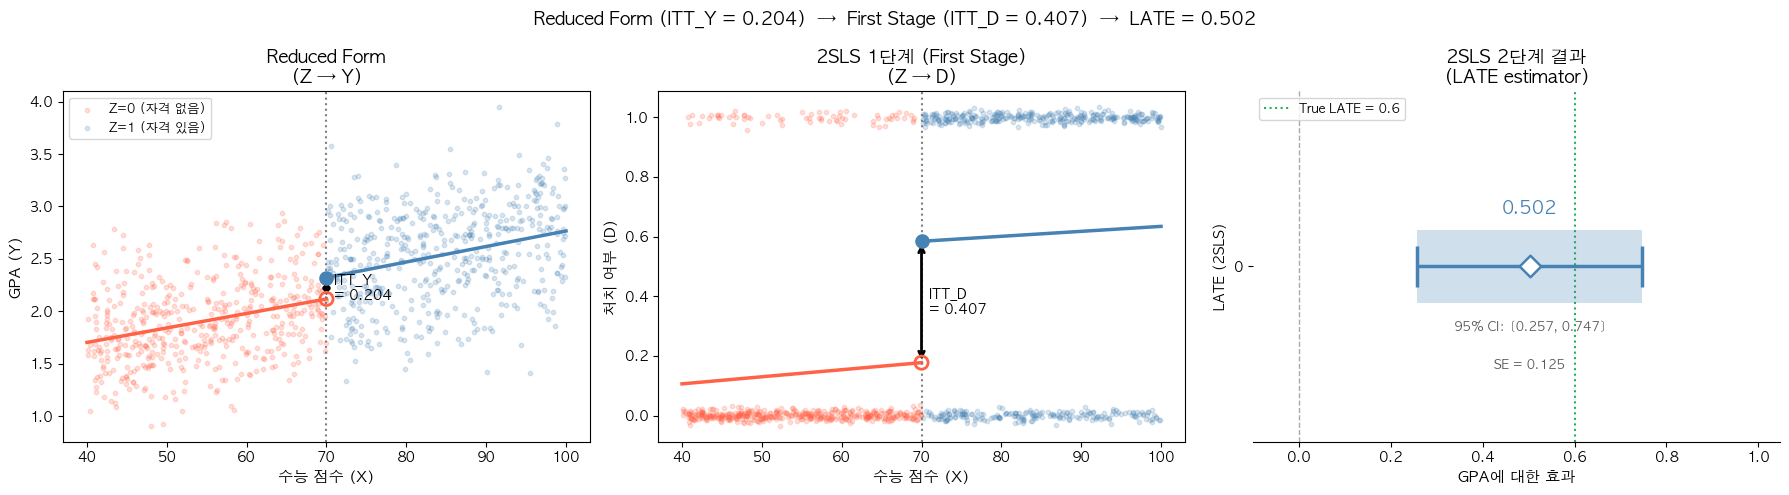

In [35]:
n = 1000
cutoff = 70
true_late = 0.6

score   = np.random.uniform(40, 100, n)
elig    = (score >= cutoff).astype(int)
treated = np.where(elig == 1,
                   np.random.binomial(1, 0.65, n),
                   np.random.binomial(1, 0.15, n))
gpa = (2.0 + 0.012*(score - cutoff)
       + true_late * treated
       + np.random.normal(0, 0.3, n))

df_viz = pd.DataFrame({'score': score, 'elig': elig,
                       'treated': treated, 'gpa': gpa,
                       'score_c': score - cutoff})

# First stage → D_hat
fs_viz = smf.ols('treated ~ elig + score_c + elig:score_c', data=df_viz).fit()
df_viz['D_hat'] = fs_viz.fittedvalues

# Second stage → LATE
ss_viz  = smf.ols('gpa ~ D_hat + score_c + D_hat:score_c', data=df_viz).fit()
LATE    = ss_viz.params['D_hat']
LATE_se = ss_viz.bse['D_hat']
LATE_ci = ss_viz.conf_int().loc['D_hat'].values   # [lower, upper]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
left  = df_viz[df_viz['elig'] == 0]
right = df_viz[df_viz['elig'] == 1]
xs_l  = np.linspace(40, cutoff, 100)
xs_r  = np.linspace(cutoff, 100, 100)

ACCENT = 'steelblue'
GREEN  = '#27ae60'
GRAY   = '#555555'

# ── 왼쪽: Reduced Form (Z → Y) ──
ax = axes[0]
ax.scatter(left['score'],  left['gpa'],  color='tomato',    alpha=0.2, s=10, label='Z=0 (자격 없음)')
ax.scatter(right['score'], right['gpa'], color='steelblue', alpha=0.2, s=10, label='Z=1 (자격 있음)')
m_y_l = smf.ols('gpa ~ score_c', data=left).fit()
m_y_r = smf.ols('gpa ~ score_c', data=right).fit()
ax.plot(xs_l, m_y_l.predict(pd.DataFrame({'score_c': xs_l - cutoff})), color='tomato',    lw=2.5)
ax.plot(xs_r, m_y_r.predict(pd.DataFrame({'score_c': xs_r - cutoff})), color='steelblue', lw=2.5)
y_l_gpa = m_y_l.params['Intercept']
y_r_gpa = m_y_r.params['Intercept']
ax.scatter([cutoff], [y_l_gpa], s=90, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax.scatter([cutoff], [y_r_gpa], s=90, color='steelblue', zorder=6)
ax.annotate('', xy=(cutoff, y_r_gpa), xytext=(cutoff, y_l_gpa),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.text(cutoff + 1, (y_l_gpa + y_r_gpa) / 2,
        f'ITT_Y\n= {y_r_gpa - y_l_gpa:.3f}', fontsize=10, fontweight='bold', va='center')
ax.axvline(cutoff, color='gray', ls=':', lw=1.5)
ax.set_title('Reduced Form\n(Z → Y)', fontsize=13, fontweight='bold')
ax.set_xlabel('수능 점수 (X)', fontsize=11)
ax.set_ylabel('GPA (Y)', fontsize=11)
ax.legend(fontsize=9)

# ── 가운데: 2SLS 1단계 (Z → D) ──
ax2 = axes[1]
ax2.scatter(left['score'],  left['treated']  + np.random.normal(0, 0.012, len(left)),
            color='tomato',    alpha=0.2, s=10)
ax2.scatter(right['score'], right['treated'] + np.random.normal(0, 0.012, len(right)),
            color='steelblue', alpha=0.2, s=10)
m_d_l = smf.ols('treated ~ score_c', data=left).fit()
m_d_r = smf.ols('treated ~ score_c', data=right).fit()
ax2.plot(xs_l, m_d_l.predict(pd.DataFrame({'score_c': xs_l - cutoff})), color='tomato',    lw=2.5)
ax2.plot(xs_r, m_d_r.predict(pd.DataFrame({'score_c': xs_r - cutoff})), color='steelblue', lw=2.5)
y_l_d = m_d_l.params['Intercept']
y_r_d = m_d_r.params['Intercept']
ax2.scatter([cutoff], [y_l_d], s=90, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax2.scatter([cutoff], [y_r_d], s=90, color='steelblue', zorder=6)
ax2.annotate('', xy=(cutoff, y_r_d), xytext=(cutoff, y_l_d),
             arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax2.text(cutoff + 1, (y_l_d + y_r_d) / 2,
         f'ITT_D\n= {y_r_d - y_l_d:.3f}', fontsize=10, fontweight='bold', va='center')
ax2.axvline(cutoff, color='gray', ls=':', lw=1.5)
ax2.set_title('2SLS 1단계 (First Stage)\n(Z → D)', fontsize=13, fontweight='bold')
ax2.set_xlabel('수능 점수 (X)', fontsize=11)
ax2.set_ylabel('처치 여부 (D)', fontsize=11)

# ── 오른쪽: Forest Plot (LATE + 95% CI) ──
ax3 = axes[2]
y_pos = 0
ax3.barh(y_pos, LATE_ci[1] - LATE_ci[0], left=LATE_ci[0],
         height=0.25, color=ACCENT, alpha=0.25, zorder=2) # CI 구간 음영
ax3.hlines(y_pos, LATE_ci[0], LATE_ci[1],
           colors=ACCENT, lw=2.5, zorder=3) # CI 수평선
ax3.vlines([LATE_ci[0], LATE_ci[1]], y_pos - 0.07, y_pos + 0.07,
           colors=ACCENT, lw=2.5, zorder=3) # 끝 캡
ax3.scatter([LATE], [y_pos], color='white', s=120,
            marker='D', zorder=5, edgecolors=ACCENT, linewidths=1.8) # 점 추정값 (다이아몬드)
ax3.axvline(true_late, color=GREEN, lw=1.5, ls=':',
            label=f'True LATE = {true_late}', zorder=1) # True effect 수직선
ax3.axvline(0, color=GRAY, lw=1, ls='--', alpha=0.5, zorder=1) # 영(0) 기준선
ax3.text(LATE, y_pos + 0.18, f'{LATE:.3f}',
         ha='center', color=ACCENT, fontsize=13, fontweight='bold')
ax3.text(LATE, y_pos - 0.22,
         f'95% CI: [{LATE_ci[0]:.3f}, {LATE_ci[1]:.3f}]',
         ha='center', color=GRAY, fontsize=9)
ax3.text(LATE, y_pos - 0.35, f'SE = {LATE_se:.3f}',
         ha='center', color=GRAY, fontsize=9)

ax3.set_xlim(min(LATE_ci[0] - 0.3, -0.1), max(LATE_ci[1] + 0.3, true_late + 0.2))
ax3.set_ylim(-0.6, 0.6)
ax3.set_yticks([0])
ax3.set_title('2SLS 2단계 결과\n(LATE estimator)', fontsize=13, fontweight='bold')
ax3.set_xlabel('GPA에 대한 효과', fontsize=11)
ax3.set_ylabel('LATE (2SLS)', fontsize=10)
ax3.legend(fontsize=9, loc='upper left')
ax3.spines[['top', 'right', 'left']].set_visible(False)

plt.suptitle(
    f'Reduced Form (ITT_Y = {y_r_gpa - y_l_gpa:.3f})  →  '
    f'First Stage (ITT_D = {y_r_d - y_l_d:.3f})  →  '
    f'LATE = {LATE:.3f}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

그래프를 보며 확인해야 할 포인트들입니다.

**왼쪽과 가운데: 점프의 크기를 비교하세요.** Reduced Form의 Y 점프($\widehat{\text{ITT}}_Y$)는 가운데 First Stage의 D 점프($\widehat{\text{ITT}}_D$)보다 작아야 합니다. Fuzzy RDD에서는 자격이 생겨도 일부만 처치를 받기 때문입니다. 만약 Y 점프가 D 점프보다 크다면 설계나 데이터에 문제가 있다는 신호입니다.

**오른쪽: 신뢰구간이 0을 포함하는지 확인하세요.** 신뢰구간이 0을 포함하면 "처치 효과가 없다는 가설"을 기각하지 못합니다. 또 True LATE(초록 점선)와 추정값(◆)이 얼마나 가까운지도 확인해보세요. 표본이 클수록 추정값이 True LATE에 가까워집니다.

**Wald 추정량을 직접 계산해 검증해보세요.** 왼쪽 그래프의 $\widehat{\text{ITT}}_Y$를 가운데 그래프의 $\widehat{\text{ITT}}_D$로 나누면 Forest Plot의 LATE와 동일한 값이 나옵니다. 전체 타이틀에도 이 관계가 요약되어 있습니다.

## 6. 활용 가능 예시

### 예시 1: 장학금 신청 자격

| 항목 | 내용 |
|------|------|
| **Running Variable** | 수능 점수 |
| **Cutoff** | 70점 |
| **Z (자격)** | 70점 이상 → 장학금 신청 자격 부여 |
| **D (처치)** | 실제 장학금 수혜 여부 |
| **Y (결과)** | GPA |

70점을 넘으면 신청 자격이 생기지만, 신청하지 않거나 서류 미비로 탈락할 수 있습니다. 반대로 일부 특별 심사를 통해 기준 미달이어도 받는 경우가 있습니다. 따라서 D가 Z를 완전히 따르지 않아 Fuzzy 설계입니다.

Wald 추정량 예시:

| | 기준 미달 (Z=0) | 기준 초과 (Z=1) |
|---|---|---|
| 실제 수혜율 (ITT_D) | 10% | 65% |
| 평균 GPA (ITT_Y) | 2.0 | 2.3 |

$$\hat{\tau}_{Fuzzy} = \frac{2.3 - 2.0}{0.65 - 0.10} = \frac{0.3}{0.55} \approx 0.55$$

→ 자격이 생겨서 장학금을 받게 된 학생들(순응자)의 GPA 향상 효과는 약 0.55점.

---

### 예시 2: 의료보험 자격 (Medicare at 65)

| 항목 | 내용 |
|------|------|
| **Running Variable** | 나이 |
| **Cutoff** | 만 65세 |
| **Z (자격)** | 65세 이상 → Medicare 가입 자격 |
| **D (처치)** | 실제 Medicare 가입 여부 |
| **Y (결과)** | 의료 이용량, 사망률 등 |

65세가 되면 Medicare 가입 자격이 생기지만 모두가 즉시 가입하지는 않습니다. 이미 직장 의료보험이 있거나, Medicaid를 쓰는 저소득층은 가입을 미루기도 합니다. Card et al.(2008)은 이 설계를 이용해 Medicare 가입이 의료 이용량과 사망률에 미치는 인과 효과를 추정했습니다.

이처럼 Fuzzy RDD는 "자격"과 "실제 수혜"가 분리될 때 자연스럽게 등장합니다.

## 7. 코드 예시 (Python)

직접 시뮬레이션을 돌려보겠습니다. 수능 70점 기준으로 장학금 신청 자격이 주어지되, **순응률(compliance rate)**이 50%인 상황을 설정합니다.

- 자격 없는 집단의 수혜율: 10% (Always-taker)
- 자격 있는 집단의 수혜율: 60% (Always-taker + Complier)
- 순응자(Complier) 비율: 60% - 10% = 50%
- 장학금의 진짜 효과 (True LATE): GPA +0.5점

In [30]:
np.random.seed(2026)
n = 1000
cutoff = 70
true_late = 0.5
p_below = 0.10   # always-taker 비율
p_above = 0.60   # always-taker + complier 비율

score   = np.random.uniform(40, 100, n)
elig    = (score >= cutoff).astype(int)            # Z_i
treated = np.where(elig == 1,
                   np.random.binomial(1, p_above, n),
                   np.random.binomial(1, p_below, n))  # D_i
gpa = (2.0
       + 0.012 * (score - cutoff)   # running variable 자연 효과
       + true_late * treated         # 처치 효과 (순응자에게만)
       + np.random.normal(0, 0.3, n))

df = pd.DataFrame({
    'score': score, 'elig': elig,
    'treated': treated, 'gpa': gpa,
    'score_c': score - cutoff,
})

print(f"전체 샘플: {n}명")
print(f"자격 없음(Z=0) - 처치율: {treated[elig==0].mean():.1%}")
print(f"자격 있음(Z=1) - 처치율: {treated[elig==1].mean():.1%}")
print(f"처치 확률 점프 (추정 순응률): {treated[elig==1].mean() - treated[elig==0].mean():.1%}")
df.head(8)

전체 샘플: 1000명
자격 없음(Z=0) - 처치율: 11.1%
자격 있음(Z=1) - 처치율: 56.9%
처치 확률 점프 (추정 순응률): 45.8%


,score,elig,treated,gpa,score_c
0,53.160738,0,0,1.606919,-16.839262
1,64.780704,0,0,2.420633,-5.219296
2,98.598129,1,0,2.733795,28.598129
3,45.333941,0,0,1.691864,-24.666059
4,68.757392,0,0,1.821720,-1.242608
5,99.253030,1,0,2.183469,29.253030
6,51.888465,0,0,1.491415,-18.111535
7,94.702911,1,0,2.066975,24.702911


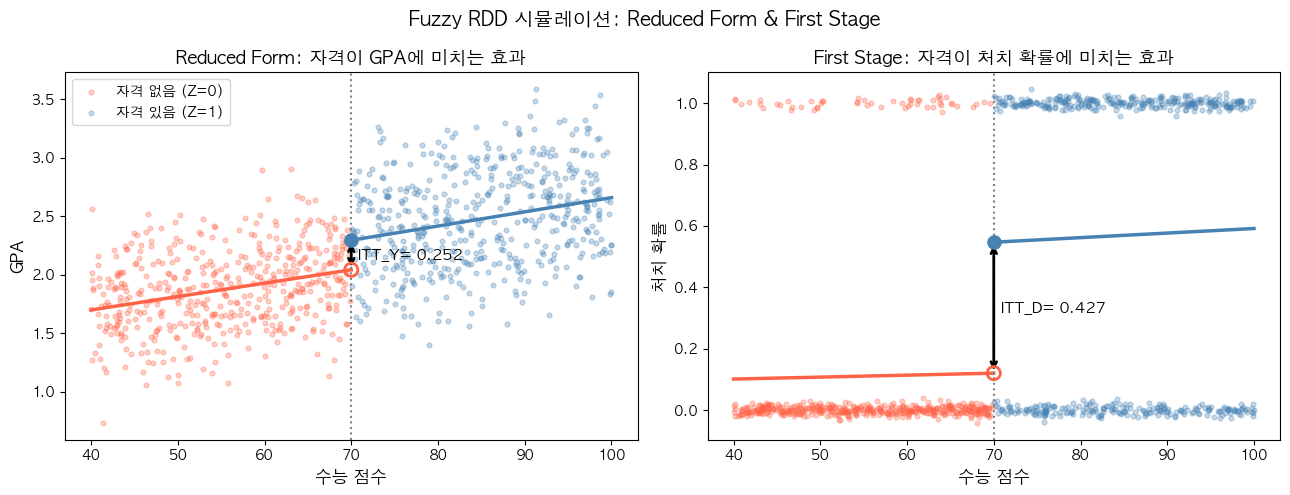

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── 왼쪽: GPA 산점도 (Reduced form) ──
ax = axes[0]
left_  = df[df['elig'] == 0]
right_ = df[df['elig'] == 1]
ax.scatter(left_['score'],  left_['gpa'],  color='tomato',    alpha=0.3, s=12, label='자격 없음 (Z=0)')
ax.scatter(right_['score'], right_['gpa'], color='steelblue', alpha=0.3, s=12, label='자격 있음 (Z=1)')

m_y_l = smf.ols('gpa ~ score_c', data=left_).fit()
m_y_r = smf.ols('gpa ~ score_c', data=right_).fit()
xs_l = np.linspace(40, cutoff, 100)
xs_r = np.linspace(cutoff, 100, 100)
ax.plot(xs_l, m_y_l.predict(pd.DataFrame({'score_c': xs_l - cutoff})), color='tomato',    lw=2.5)
ax.plot(xs_r, m_y_r.predict(pd.DataFrame({'score_c': xs_r - cutoff})), color='steelblue', lw=2.5)
y_l_gpa = m_y_l.params['Intercept']
y_r_gpa = m_y_r.params['Intercept']
ax.scatter([cutoff], [y_l_gpa], s=90, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax.scatter([cutoff], [y_r_gpa], s=90, color='steelblue', zorder=6)
ax.annotate('', xy=(cutoff, y_r_gpa), xytext=(cutoff, y_l_gpa),
            arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax.text(cutoff + 0.8, (y_l_gpa + y_r_gpa)/2,
        f'ITT_Y= {y_r_gpa - y_l_gpa:.3f}', fontsize=11, fontweight='bold', va='center')
ax.axvline(cutoff, color='gray', ls=':', lw=1.5)
ax.set_title('Reduced Form: 자격이 GPA에 미치는 효과', fontsize=13, fontweight='bold')
ax.set_xlabel('수능 점수', fontsize=12); ax.set_ylabel('GPA', fontsize=12)
ax.legend(fontsize=10)

# ── 오른쪽: 처치 확률 (First stage) ──
ax2 = axes[1]
ax2.scatter(left_['score'],  left_['treated']  + np.random.normal(0, 0.012, len(left_)),  color='tomato',    alpha=0.3, s=12)
ax2.scatter(right_['score'], right_['treated'] + np.random.normal(0, 0.012, len(right_)), color='steelblue', alpha=0.3, s=12)

m_d_l = smf.ols('treated ~ score_c', data=left_).fit()
m_d_r = smf.ols('treated ~ score_c', data=right_).fit()
ax2.plot(xs_l, m_d_l.predict(pd.DataFrame({'score_c': xs_l - cutoff})), color='tomato',    lw=2.5)
ax2.plot(xs_r, m_d_r.predict(pd.DataFrame({'score_c': xs_r - cutoff})), color='steelblue', lw=2.5)
y_l_d = m_d_l.params['Intercept']
y_r_d = m_d_r.params['Intercept']
ax2.scatter([cutoff], [y_l_d], s=90, color='tomato',    zorder=6, facecolors='none', edgecolors='tomato', linewidths=2)
ax2.scatter([cutoff], [y_r_d], s=90, color='steelblue', zorder=6)
ax2.annotate('', xy=(cutoff, y_r_d), xytext=(cutoff, y_l_d),
             arrowprops=dict(arrowstyle='<->', color='black', lw=2))
ax2.text(cutoff + 0.8, (y_l_d + y_r_d)/2,
         f'ITT_D= {y_r_d - y_l_d:.3f}', fontsize=11, fontweight='bold', va='center')
ax2.axvline(cutoff, color='gray', ls=':', lw=1.5)
ax2.set_title('First Stage: 자격이 처치 확률에 미치는 효과', fontsize=13, fontweight='bold')
ax2.set_xlabel('수능 점수', fontsize=12); ax2.set_ylabel('처치 확률', fontsize=12)

plt.suptitle('Fuzzy RDD 시뮬레이션: Reduced Form & First Stage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
# ── Wald 추정량으로 LATE 계산 ──
itt_y = y_r_gpa - y_l_gpa
itt_d = y_r_d   - y_l_d
late_wald = itt_y / itt_d

print("=" * 45)
print(f"  ITT_Y (Reduced form 점프) : {itt_y:.4f}")
print(f"  ITT_D (First stage 점프)  : {itt_d:.4f}")
print("-" * 45)
print(f"  Wald LATE = ITT_Y / ITT_D : {late_wald:.4f}")
print(f"  진짜 LATE                  : {true_late}")
print("=" * 45)

  ITT_Y (Reduced form 점프) : 0.2522
  ITT_D (First stage 점프)  : 0.4267
---------------------------------------------
  Wald LATE = ITT_Y / ITT_D : 0.5911
  진짜 LATE                  : 0.5


In [34]:
# ── 수동 2SLS ──
# 1단계: D ~ Z + score_c + Z*score_c
fs = smf.ols('treated ~ elig + score_c + elig:score_c', data=df).fit()
df['D_hat'] = fs.fittedvalues

# F-통계량 (elig 계수에 대한 t² ≈ F)
f_stat = (fs.params['elig'] / fs.bse['elig']) ** 2

# 2단계: Y ~ D_hat + score_c + D_hat*score_c
ss = smf.ols('gpa ~ D_hat + score_c + D_hat:score_c', data=df).fit()

print("=" * 50)
print("  [1단계 First Stage]")
print(f"  α₁ (처치 확률 점프)  : {fs.params['elig']:.4f}")
print(f"  F-통계량 (≥10이면 강한 IV): {f_stat:.1f}")
print()
print("  [2단계 Second Stage]")
print(f"  β₁ (LATE 추정치)    : {ss.params['D_hat']:.4f}")
print(f"  진짜 LATE           : {true_late}")
print("=" * 50)
print()
print("  * 표준오차는 linearmodels 등 IV 패키지로 추정해야 정확합니다.")

  [1단계 First Stage]
  α₁ (처치 확률 점프)  : 0.4267
  F-통계량 (≥10이면 강한 IV): 67.1

  [2단계 Second Stage]
  β₁ (LATE 추정치)    : 0.5912
  진짜 LATE           : 0.5

  * 표준오차는 linearmodels 등 IV 패키지로 추정해야 정확합니다.


## 참고 자료

- [인과추론의 데이터과학 (Youtube)](https://www.youtube.com/watch?v=8SIoMJTmO3A)
- Imbens, G. W., & Lemieux, T. (2008). Regression discontinuity designs: A guide to practice. *Journal of Econometrics*, 142(2), 615–635.
- Hahn, J., Todd, P., & Van der Klaauw, W. (2001). Identification and estimation of treatment effects with a regression-discontinuity design. *Econometrica*, 69(1), 201–209.
- Card, D., Dobkin, C., & Maestas, N. (2008). The impact of nearly universal insurance coverage on health care utilization: Evidence from Medicare. *American Economic Review*, 98(5), 2242–2258.
- Cattaneo, M. D., Idrobo, N., & Titiunik, R. (2019). *A Practical Introduction to Regression Discontinuity Designs*. Cambridge University Press.